In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [39]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN

In [40]:
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
)

In [41]:
df = pd.read_csv("OR_hos_prices1.csv")

In [42]:
df.shape

(59, 84)

In [43]:
df.head()

,Unnamed: 0,address,lat,long,Cardiovascular: Electrophysiology,Thyroidectomy,Nuclear Medicine: Musculoskeletal,Central Line,Breast Reconstruction,Arthorcentesis,...,CT scan: Head and Neck,Radiation Treatment: Guidance,MRI: Head and Neck,Cesarean Section with complications,Cardiovascular: Echocardiography,CT scan: Chest,Hysteroscopy,CVC Insertion,Breast Biopsy,Tonsillectomy
0,Mid-Columbia Medical Center,"1700 E 19th St, The Dalles, OR 97058, USA",45.587210,-121.164857,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,2078.0,NaN,NaN,NaN,NaN,NaN
1,Asante Three Rivers Medical Center,"500 SW Ramsey Ave, Grants Pass, OR 97527, USA",42.421363,-123.342914,NaN,NaN,1384.0,NaN,NaN,931.0,...,468.0,NaN,NaN,NaN,1595.0,468.0,6397.0,6704.0,3864.0,5434.0
2,Providence St Vincent Medical Center,"9205 SW Barnes Rd, Portland, OR 97225, USA",45.510438,-122.771628,39084.0,14045.0,593.0,22032.0,7133.0,655.0,...,506.0,683.0,569.0,19183.0,1354.0,242.0,4900.0,4900.0,3319.0,5180.0
3,Asante Ashland Community Hospital,"280 Maple St, Ashland, OR 97520, USA",42.205650,-122.724803,NaN,NaN,NaN,NaN,NaN,NaN,...,1032.0,NaN,NaN,NaN,1635.0,1408.0,NaN,NaN,3573.0,NaN
4,Legacy Emanuel Medical Center,"2801 N Gantenbein Ave, Portland, OR 97227, USA",45.544170,-122.669685,48813.0,12222.0,NaN,48628.0,NaN,NaN,...,433.0,NaN,835.0,15733.0,1273.0,NaN,NaN,NaN,NaN,6599.0


In [44]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 59 entries, 0 to 58
Data columns (total 84 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   Unnamed: 0                                       59 non-null     str    
 1   address                                          59 non-null     str    
 2   lat                                              59 non-null     float64
 3   long                                             59 non-null     float64
 4   Cardiovascular: Electrophysiology                11 non-null     float64
 5   Thyroidectomy                                    12 non-null     float64
 6   Nuclear Medicine: Musculoskeletal                23 non-null     float64
 7   Central Line                                     12 non-null     float64
 8   Breast Reconstruction                            10 non-null     float64
 9   Arthorcentesis                               

In [45]:
df.columns.tolist()

['Unnamed: 0',
 'address',
 'lat',
 'long',
 'Cardiovascular: Electrophysiology',
 'Thyroidectomy',
 'Nuclear Medicine: Musculoskeletal',
 'Central Line',
 'Breast Reconstruction',
 'Arthorcentesis',
 'CT scan with contrast: Head and Neck',
 'Radiation Treatment: Consult',
 'Chemotherapy: Injection',
 'Cardiovascular: Catheterization',
 'Nuclear Medicine: Cardiovascular',
 'Bone Study',
 'X-ray: Chest',
 'Ultrasound: Obstetrical',
 'Hysterectomy',
 'Cesarean Section without complications',
 'Radiation Treatment: Dosimetry',
 'Bowel Removal',
 'Cataract',
 'Cystoscopy Lithotripsy',
 'Cardiovascular: Electrocardiography',
 'Cardiovascular: Mobile Heart Monitoring',
 'X-ray: Spine',
 'Spinal laminectomy',
 'Chemotherapy: IV infusion',
 'CT scan: Abdomen/GI',
 'Newborn care without complications',
 'Spinal Tap',
 'CT scan with contrast: Abdomen/GI',
 'Nuclear Medicine: Endocrine',
 'Radiation Treatment: Simulations & Film',
 'MRI: Spine',
 'PTCA',
 'MRI with contrast: Extremities',
 'MRI w

In [46]:
df.duplicated().sum()

np.int64(0)

In [47]:
df["Unnamed: 0"].nunique()

59

In [48]:
missing = df.isna().mean().sort_values(ascending=False)
missing.head(15)

Radiation Treatment: Guidance        0.898305
Spinal Tap                           0.864407
Blood Transfusion                    0.847458
Breast Reconstruction                0.830508
Coronary Bypass                      0.813559
Cardiovascular: Electrophysiology    0.813559
Abdominal Drainage                   0.813559
Lesion Removal                       0.796610
Thyroidectomy                        0.796610
MRI with contrast: Spine             0.796610
Central Line                         0.796610
Nerve Block                          0.779661
Mastectomy                           0.779661
Spinal injection                     0.779661
Chemotherapy: Injection              0.762712
dtype: float64

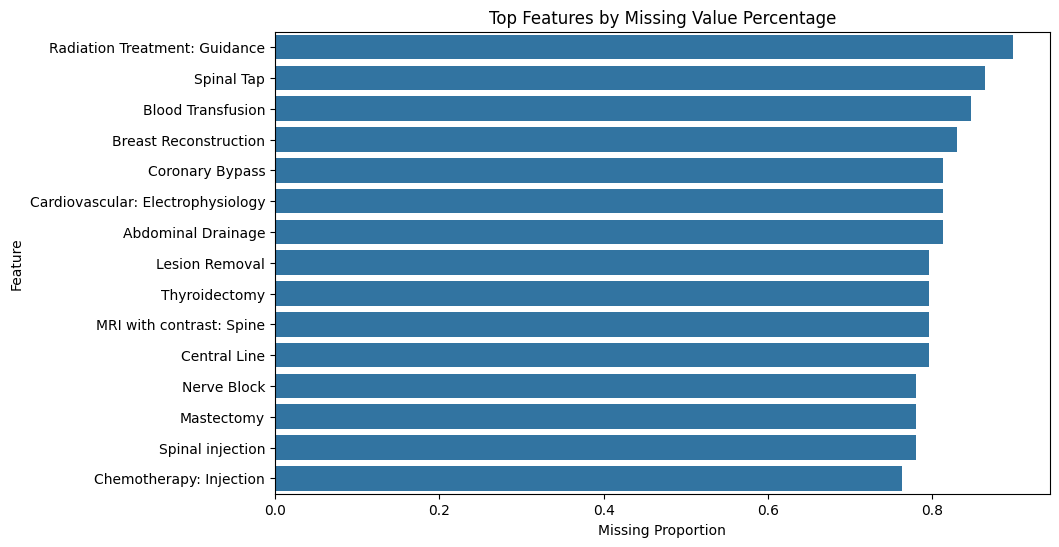

In [49]:
plt.figure(figsize=(10, 6))
sns.barplot(x=missing.head(15).values, y=missing.head(15).index)
plt.title("Top Features by Missing Value Percentage")
plt.xlabel("Missing Proportion")
plt.ylabel("Feature")
plt.show()

In [50]:
hospital_names = df["Unnamed: 0"]

In [51]:
data = df.drop(columns=["Unnamed: 0", "address"])

In [52]:
data = data.drop(columns=["lat", "long"])

In [53]:
data = data.fillna(0)

In [54]:
data.isna().sum().sum()

np.int64(0)

In [55]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Cardiovascular: Electrophysiology,59.0,7590.220339,16598.638037,0.0,0.0,0.0,0.0,57677.0
Thyroidectomy,59.0,2739.745763,5610.001677,0.0,0.0,0.0,0.0,16916.0
Nuclear Medicine: Musculoskeletal,59.0,379.542373,513.892996,0.0,0.0,0.0,919.5,1453.0
Central Line,59.0,5771.203390,12040.161273,0.0,0.0,0.0,0.0,48628.0
Breast Reconstruction,59.0,2426.610169,5754.075980,0.0,0.0,0.0,0.0,20482.0
...,...,...,...,...,...,...,...,...
CT scan: Chest,59.0,331.033898,428.839170,0.0,0.0,242.0,486.0,1465.0
Hysteroscopy,59.0,3323.033898,3703.939692,0.0,0.0,0.0,6719.5,11439.0
CVC Insertion,59.0,1702.406780,2866.640086,0.0,0.0,0.0,3853.0,9097.0
Breast Biopsy,59.0,1302.254237,1604.569118,0.0,0.0,0.0,3073.5,5034.0


In [56]:
X = np.log1p(data)

In [57]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [58]:
inertia = []
for k in range(2, 9):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    inertia.append(model.inertia_)

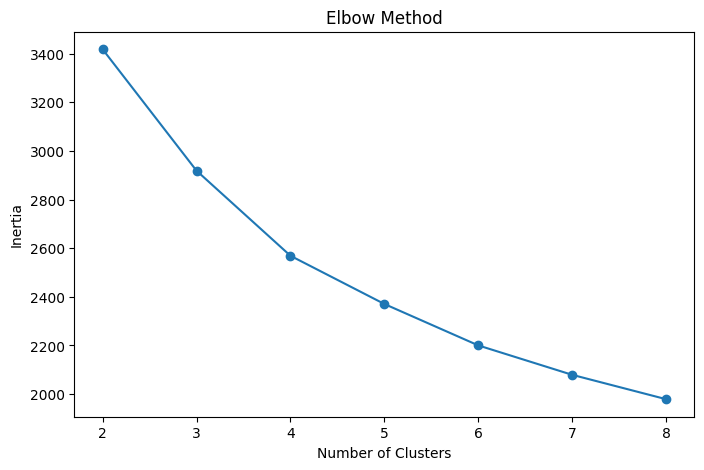

In [59]:
plt.figure(figsize=(8, 5))
plt.plot(range(2, 9), inertia, marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

In [60]:
silhouette_scores = []
for k in range(2, 9):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

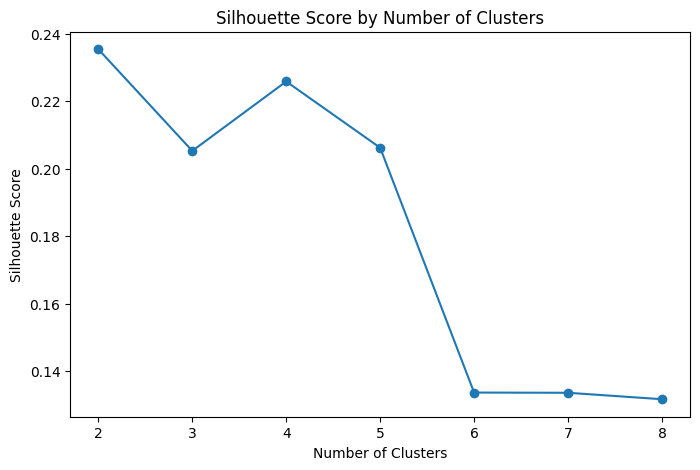

In [61]:
plt.figure(figsize=(8, 5))
plt.plot(range(2, 9), silhouette_scores, marker="o")
plt.title("Silhouette Score by Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.show()

In [62]:
best_k = range(2, 9)[np.argmax(silhouette_scores)]
best_k

2

In [63]:
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

In [64]:
df["KMeans_Cluster"] = kmeans_labels

In [65]:
agg = AgglomerativeClustering(n_clusters=best_k)
agg_labels = agg.fit_predict(X_scaled)

In [66]:
df["Agglomerative_Cluster"] = agg_labels

In [67]:
dbscan = DBSCAN(eps=3, min_samples=3)
db_labels = dbscan.fit_predict(X_scaled)

In [68]:
pd.Series(db_labels).value_counts()

-1    59
Name: count, dtype: int64

In [69]:
cluster_results = []

In [70]:
cluster_results.append(
    {
        "Model": "K-Means",
        "Silhouette": silhouette_score(X_scaled, kmeans_labels),
        "Calinski-Harabasz": calinski_harabasz_score(X_scaled, kmeans_labels),
        "Davies-Bouldin": davies_bouldin_score(X_scaled, kmeans_labels),
    }
)

In [71]:
cluster_results.append(
    {
        "Model": "Agglomerative",
        "Silhouette": silhouette_score(X_scaled, agg_labels),
        "Calinski-Harabasz": calinski_harabasz_score(X_scaled, agg_labels),
        "Davies-Bouldin": davies_bouldin_score(X_scaled, agg_labels),
    }
)

In [72]:
db_valid = db_labels != -1
if len(set(db_labels[db_valid])) > 1:
    cluster_results.append(
        {
            "Model": "DBSCAN",
            "Silhouette": silhouette_score(X_scaled[db_valid], db_labels[db_valid]),
            "Calinski-Harabasz": calinski_harabasz_score(
                X_scaled[db_valid], db_labels[db_valid]
            ),
            "Davies-Bouldin": davies_bouldin_score(
                X_scaled[db_valid], db_labels[db_valid]
            ),
        }
    )

In [74]:
missing_pct = data.isna().mean().sort_values(ascending=False)
missing_pct.describe()

count    80.0
mean      0.0
std       0.0
min       0.0
25%       0.0
50%       0.0
75%       0.0
max       0.0
dtype: float64

In [75]:
missing_pct.head(20)

Cardiovascular: Electrophysiology         0.0
Thyroidectomy                             0.0
Nuclear Medicine: Musculoskeletal         0.0
Central Line                              0.0
Breast Reconstruction                     0.0
Arthorcentesis                            0.0
CT scan with contrast: Head and Neck      0.0
Radiation Treatment: Consult              0.0
Chemotherapy: Injection                   0.0
Cardiovascular: Catheterization           0.0
Nuclear Medicine: Cardiovascular          0.0
Bone Study                                0.0
X-ray: Chest                              0.0
Ultrasound: Obstetrical                   0.0
Hysterectomy                              0.0
Cesarean Section without complications    0.0
Radiation Treatment: Dosimetry            0.0
Bowel Removal                             0.0
Cataract                                  0.0
Cystoscopy Lithotripsy                    0.0
dtype: float64

In [76]:
keep_cols = missing_pct[missing_pct <= 0.70].index
data = data[keep_cols]

In [77]:
data.shape

(59, 80)

In [78]:
data = data.fillna(0)

In [79]:
data = data.fillna(data.median())

In [80]:
data.isna().sum().sum()

np.int64(0)

In [81]:
X = np.log1p(data)

In [82]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [83]:
from sklearn.decomposition import PCA

In [84]:
pca = PCA(n_components=0.90)
X_pca = pca.fit_transform(X_scaled)
X_pca.shape

(59, 22)

In [85]:
pca.n_components_

np.int64(22)

In [86]:
inertia = []
silhouette_scores = []
for k in range(2, 8):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_pca)
    inertia.append(model.inertia_)
    silhouette_scores.append(silhouette_score(X_pca, labels))

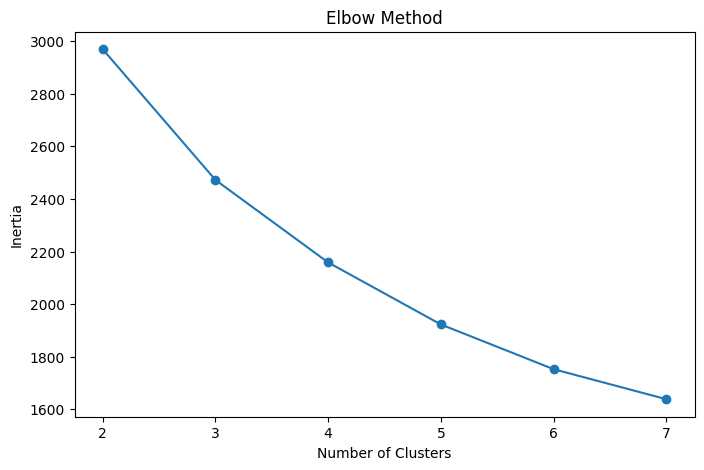

In [87]:
plt.figure(figsize=(8, 5))
plt.plot(range(2, 8), inertia, marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

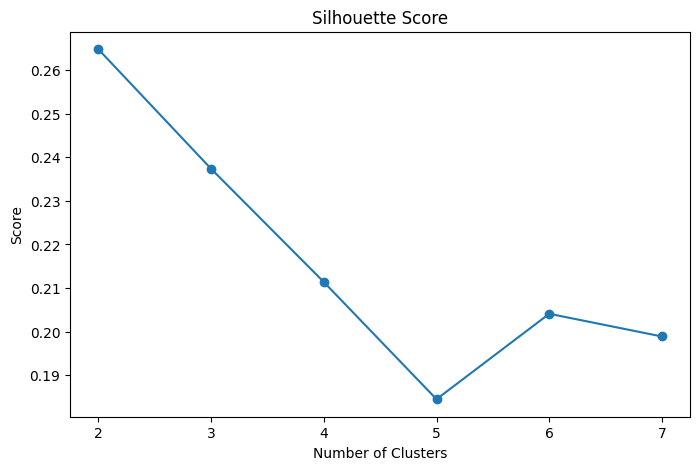

In [88]:
plt.figure(figsize=(8, 5))
plt.plot(range(2, 8), silhouette_scores, marker="o")
plt.title("Silhouette Score")
plt.xlabel("Number of Clusters")
plt.ylabel("Score")
plt.show()

In [89]:
pd.DataFrame({"Clusters": range(2, 8), "Silhouette": silhouette_scores}).round(3)

,Clusters,Silhouette
0,2,0.265
1,3,0.237
2,4,0.211
3,5,0.184
4,6,0.204
5,7,0.199


In [90]:
list(zip(range(2, 8), np.round(silhouette_scores, 3)))

[(2, np.float64(0.265)),
 (3, np.float64(0.237)),
 (4, np.float64(0.211)),
 (5, np.float64(0.184)),
 (6, np.float64(0.204)),
 (7, np.float64(0.199))]

In [91]:
best_k = 2
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_pca)

In [92]:
df["KMeans_Cluster"] = kmeans_labels

In [93]:
df["KMeans_Cluster"].value_counts()

KMeans_Cluster
1    30
0    29
Name: count, dtype: int64

In [94]:
agg = AgglomerativeClustering(n_clusters=2)
agg_labels = agg.fit_predict(X_pca)

In [95]:
df["Agglomerative_Cluster"] = agg_labels

In [96]:
pd.Series(agg_labels).value_counts()

1    30
0    29
Name: count, dtype: int64

In [97]:
dbscan = DBSCAN(eps=1.5, min_samples=3)
db_labels = dbscan.fit_predict(X_pca)

In [98]:
pd.Series(db_labels).value_counts()

-1    59
Name: count, dtype: int64

In [99]:
cluster_results = []

In [100]:
cluster_results.append(
    {
        "Model": "K-Means",
        "Silhouette": silhouette_score(X_pca, kmeans_labels),
        "Calinski-Harabasz": calinski_harabasz_score(X_pca, kmeans_labels),
        "Davies-Bouldin": davies_bouldin_score(X_pca, kmeans_labels),
    }
)

In [101]:
cluster_results.append(
    {
        "Model": "Agglomerative",
        "Silhouette": silhouette_score(X_pca, agg_labels),
        "Calinski-Harabasz": calinski_harabasz_score(X_pca, agg_labels),
        "Davies-Bouldin": davies_bouldin_score(X_pca, agg_labels),
    }
)

In [103]:
valid = db_labels != -1

if len(set(db_labels[valid])) > 1:

    cluster_results.append(
        {
            "Model": "DBSCAN",
            "Silhouette": silhouette_score(X_pca[valid], db_labels[valid]),
            "Calinski-Harabasz": calinski_harabasz_score(
                X_pca[valid], db_labels[valid]
            ),
            "Davies-Bouldin": davies_bouldin_score(X_pca[valid], db_labels[valid]),
        }
    )

In [104]:
cluster_results = pd.DataFrame(cluster_results)
cluster_results.round(3)

,Model,Silhouette,Calinski-Harabasz,Davies-Bouldin
0,K-Means,0.265,24.957,1.453
1,Agglomerative,0.265,24.957,1.453


In [105]:
plot_df = pd.DataFrame(
    {"PC1": X_pca[:, 0], "PC2": X_pca[:, 1], "Cluster": kmeans_labels}
)

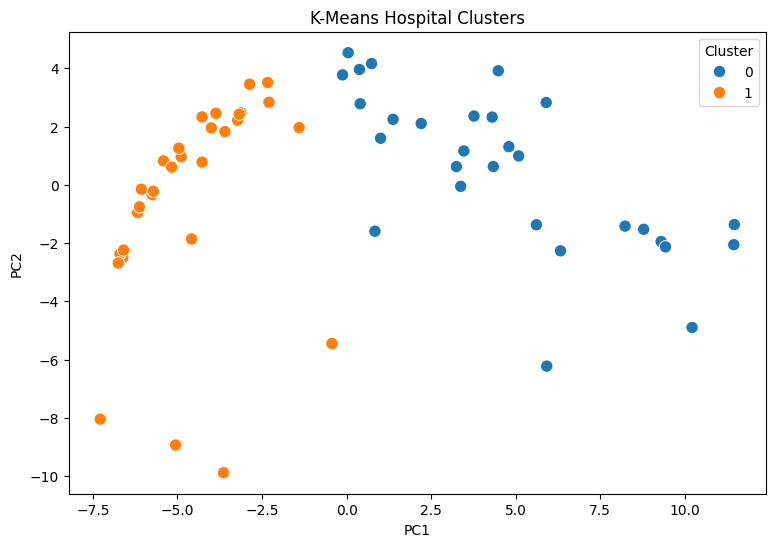

In [106]:
plt.figure(figsize=(9, 6))

sns.scatterplot(data=plot_df, x="PC1", y="PC2", hue="Cluster", s=80)

plt.title("K-Means Hospital Clusters")
plt.show()

In [107]:
hospital_clusters = pd.DataFrame({"Hospital": hospital_names, "Cluster": kmeans_labels})

In [108]:
hospital_clusters.sort_values("Cluster")

,Hospital,Cluster
1,Asante Three Rivers Medical Center,0
2,Providence St Vincent Medical Center,0
5,OHSU Hospital,0
4,Legacy Emanuel Medical Center,0
6,Good Samaritan Regional Medical Center,0
7,Legacy Good Samaritan Medical Center,0
9,McKenzie-Willamette Medical Center,0
8,Asante Rogue Regional Medical center,0
12,Legacy Mount Hood Medical Center,0
13,Mercy Medical Center,0


In [109]:
cluster_data = data.copy()

cluster_data["Cluster"] = kmeans_labels

In [110]:
cluster_means = cluster_data.groupby("Cluster").mean()

In [111]:
cluster_diff = (
    (cluster_means.loc[0] - cluster_means.loc[1]).abs().sort_values(ascending=False)
)

In [112]:
cluster_diff.head(15)

Coronary Bypass                           26961.675862
Spinal Fusion                             26174.427586
Knee Replacement                          25510.937931
Hip Replacement                           20910.601149
PTCA                                      17980.689655
Bowel Removal                             16677.757471
Cardiovascular: Electrophysiology         12860.888506
Cesarean Section with complications       12006.706897
Hysterectomy                              11486.977011
Cesarean Section without complications    10892.390805
Central Line                               9385.279310
ORIF                                       8055.286207
Gallbladder                                7724.906897
Newborn care with complications            6999.570115
Blood Transfusion                          6817.482759
dtype: float64

In [113]:
top_features = cluster_diff.head(10).index

cluster_means[top_features].T

Cluster,0,1
Coronary Bypass,30665.275862,3703.600000
Spinal Fusion,28229.827586,2055.400000
Knee Replacement,29651.137931,4140.200000
Hip Replacement,22444.034483,1533.433333
PTCA,20658.689655,2678.000000
Bowel Removal,18047.724138,1369.966667
Cardiovascular: Electrophysiology,14129.655172,1268.766667
Cesarean Section with complications,13519.206897,1512.500000
Hysterectomy,15208.310345,3721.333333
Cesarean Section without complications,11954.724138,1062.333333


In [114]:
cluster_diff.head(15)

Coronary Bypass                           26961.675862
Spinal Fusion                             26174.427586
Knee Replacement                          25510.937931
Hip Replacement                           20910.601149
PTCA                                      17980.689655
Bowel Removal                             16677.757471
Cardiovascular: Electrophysiology         12860.888506
Cesarean Section with complications       12006.706897
Hysterectomy                              11486.977011
Cesarean Section without complications    10892.390805
Central Line                               9385.279310
ORIF                                       8055.286207
Gallbladder                                7724.906897
Newborn care with complications            6999.570115
Blood Transfusion                          6817.482759
dtype: float64

In [115]:
cluster_avg = cluster_data.groupby("Cluster").mean().mean(axis=1)

cluster_avg

Cluster
0    4593.806897
1     838.874583
dtype: float64

In [116]:
cluster_avg[0] / cluster_avg[1]

np.float64(5.476154585942844)

In [117]:
top_features = cluster_diff.head(10).index

profile = cluster_means[top_features].T

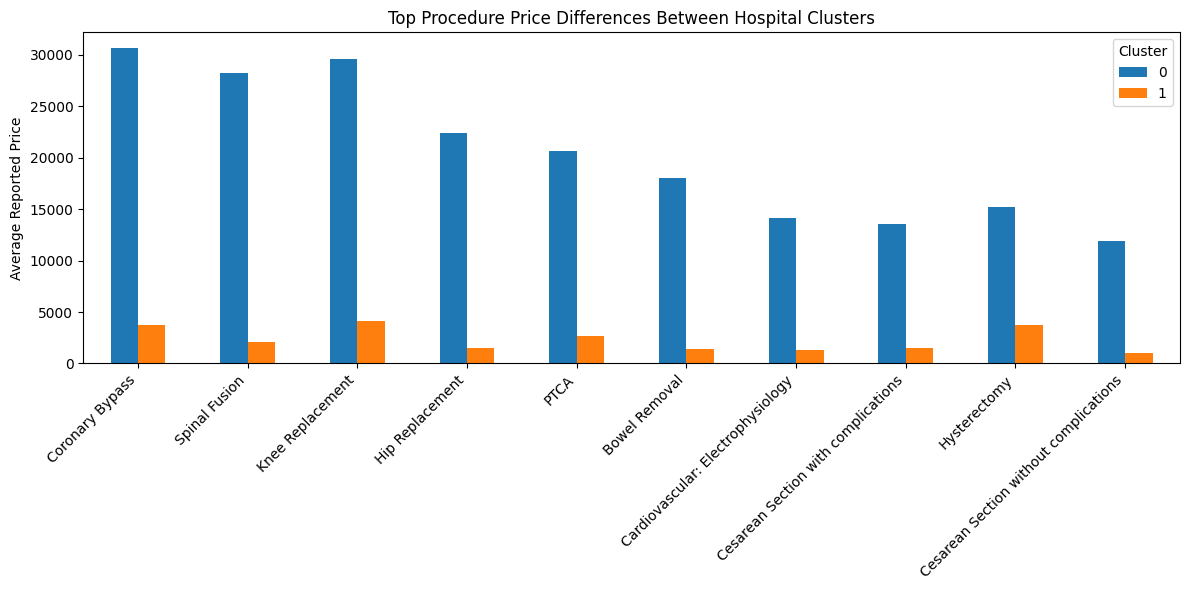

In [118]:
profile.plot(kind="bar", figsize=(12, 6))

plt.title("Top Procedure Price Differences Between Hospital Clusters")
plt.ylabel("Average Reported Price")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [119]:
hospital_clusters["Cluster"].value_counts()

Cluster
1    30
0    29
Name: count, dtype: int64

In [120]:
cluster_names = {0: "Higher Price Group", 1: "Lower Price Group"}

hospital_clusters["Price_Group"] = hospital_clusters["Cluster"].map(cluster_names)

In [121]:
hospital_clusters.head()

,Hospital,Cluster,Price_Group
0,Mid-Columbia Medical Center,1,Lower Price Group
1,Asante Three Rivers Medical Center,0,Higher Price Group
2,Providence St Vincent Medical Center,0,Higher Price Group
3,Asante Ashland Community Hospital,1,Lower Price Group
4,Legacy Emanuel Medical Center,0,Higher Price Group


In [122]:
geo_clusters = df[["Unnamed: 0", "lat", "long"]].copy()

geo_clusters["Cluster"] = kmeans_labels

In [123]:
geo_clusters.groupby("Cluster")[["lat", "long"]].mean()

,lat,long
Cluster,,
0,44.771133,-122.413227
1,44.328579,-121.989642


In [124]:
cluster_results.round(3)

,Model,Silhouette,Calinski-Harabasz,Davies-Bouldin
0,K-Means,0.265,24.957,1.453
1,Agglomerative,0.265,24.957,1.453
